In [1]:
from prometheus_pandas import query
import datetime as dt
from zoneinfo import ZoneInfo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

local_address = "gros-95.nancy.grid5000.fr"
local_port = "30090"
p = query.Prometheus(f"http://admin:prom-operator@{local_address}:{local_port}")    

local_tz = ZoneInfo("Europe/Paris")

def execute_query_range(experiment, metric_query, step, output_filename, plot=False):
    tput_series = []

    print("\nBeginning request execution")
    for label, config in experiment.items():    
        df_metric = p.query_range(
            query=metric_query,
            start=config['start'].isoformat(),
            end=config['end'].isoformat(),
            step=step
        )

        tput_series.append(df_metric)

    if tput_series:
        combined_df = pd.concat(tput_series, axis=1)
        combined_df.to_csv(output_filename, index_label='Time')
        print(f"\nFile saved : '{output_filename}'")
        if plot:
            plt.figure(figsize=(12, 8))
            ax = combined_df.boxplot(grid=True, patch_artist=True)
            plt.title(metric_query)
            plt.show()
    else:
        print("\nRequest Error")

### Experiment 1f

In [ ]:
exp_update = { 
    'rocks': {
        'start': dt.datetime(2025, 8, 21, 11, 28, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 21, 11, 38, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 8, 21, 11, 42, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 21, 11, 52, 0, tzinfo=local_tz)
    },
    'forst (no cache)': {
        'start': dt.datetime(2025, 8, 21, 11, 57, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 21, 12, 7, 0, tzinfo=local_tz)
    }
}

### Queries

In [ ]:
metric_query = 'sum(rate(flink_taskmanager_job_task_operator_numRecordsOut{operator_name=~"Source:.*"}[1m]))'
step = "5s"
output_filename = 'exp1a_tput.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'flink_taskmanager_Status_JVM_CPU_Load{component="taskmanager"}'
step = "5s"
output_filename = 'exp1a_cpu_load.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointDuration{component="jobmanager"}'
step = "30s"
output_filename = 'exp1a_cp_time.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_receive_bytes_total{namespace="minio-tenant", pod=~"myminio-.*"}[2m]))'
step = "5s"
output_filename = 'exp1a_minio_bytes_receive.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_transmit_bytes_total{namespace="minio-tenant", pod=~"myminio-.*"}[2m]))'
step = "5s"
output_filename = 'exp1a_minio_bytes_send.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(flink_taskmanager_job_task_operator_column_family_rocksdb_total_sst_files_size{component="taskmanager"})'
step = "5s"
output_filename = 'exp1a_sst_size.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_transmit_bytes_total{node="gros-98.nancy.grid5000.fr"}[2m]))'
step = "5s"
output_filename = 'exp1a_tm_bytes_send.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_receive_bytes_total{node="gros-98.nancy.grid5000.fr"}[2m]))'
step = "5s"
output_filename = 'exp1a_tm_bytes_received.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointSize{component="jobmanager"}'
step = "60s"
output_filename = 'exp1a_cp_size.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[2m]))/(sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_miss{component="taskmanager"}[2m]))+sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[2m])))'
step = "5s"
output_filename = 'exp1a_cache_hit_ratio.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'rate(minio_bucket_traffic_received_bytes{job="minio"}[2m])'
step = "1m"
output_filename = 'exp1a_bucket_received_bytes_rate.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'rate(minio_node_io_rchar_bytes{job=~"minio"}[2m])'
step = "1m"
output_filename = 'exp1a_read_bytes_rate.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'rate(minio_node_io_wchar_bytes{job=~"minio"}[2m])'
step = "1m"
output_filename = 'exp1a_write_bytes_rate.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(minio_node_drive_used_bytes{job=~"minio"})'
step = "1m"
output_filename = 'exp1a_drive_used_bytes.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum by (api) (minio_node_drive_latency_us{job=~"minio"})'
step = "1m"
output_filename = 'exp1a_operation_latency.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = '(increase(minio_bucket_requests_total{job="minio"}[2m]))'
step = "1m"
output_filename = 'exp1a_operation_request_rate.csv' #type of operation (create/get/delete/... and its rate)
execute_query_range(exp_write, metric_query, step, output_filename)


Beginning request execution

File saved : 'exp1f_tput.csv'

Beginning request execution

File saved : 'exp1f_cpu_load.csv'

Beginning request execution

File saved : 'exp1f_cp_time.csv'

Beginning request execution

File saved : 'exp1f_minio_bytes_receive.csv'

Beginning request execution

File saved : 'exp1f_minio_bytes_send.csv'

Beginning request execution

File saved : 'exp1f_sst_size.csv'

Beginning request execution

File saved : 'exp1f_tm_bytes_send.csv'

Beginning request execution

File saved : 'exp1f_tm_bytes_received.csv'

Beginning request execution

File saved : 'exp1f_cp_size.csv'

Beginning request execution

File saved : 'exp1f_cache_hit_ratio.csv'

Beginning request execution

File saved : 'exp1f_bucket_received_bytes_rate.csv'

Beginning request execution

File saved : 'exp1f_read_bytes_rate.csv'

Beginning request execution

File saved : 'exp1f_write_bytes_rate.csv'

Beginning request execution

File saved : 'exp1f_drive_used_bytes.csv'

Beginning request execution


### Boxplot from file

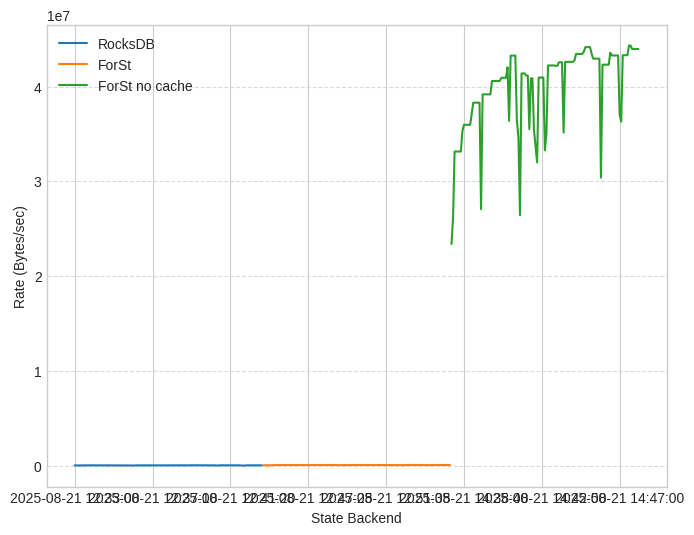

In [ ]:
file_path = 'exp1a_minio_bytes_send.csv'

try:
    df = pd.read_csv(file_path, index_col=0)
    
    df.columns = ['RocksDB', 'ForSt', 'ForSt no cache']
    #df = df.iloc[:, :-1] 

    plt.figure(figsize=(8, 6))
    df.plot(grid=True, ax=plt.gca()) #style='o'
    plt.style.use('seaborn-v0_8-whitegrid')
    #df.boxplot(grid=False, patch_artist=True)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    #plt.title('CPU Load over time for large state job')
    plt.ylabel('Rate (Bytes/sec)')
    plt.xlabel('State Backend')
    #plt.yticks(np.arange(0, 1.2, 0.2))
    plt.savefig('exp1a_minio_bytes_send.pdf')
    
    plt.show()
    
except FileNotFoundError:
    print(f"Le fichier '{file_path}' est introuvable.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")